In [1]:
using SparseArrays, LinearAlgebra, Tullio
using Expokit   # si no lo tienes: ] add Expokit

⊗(A,B) = kron(A,B) ;
# import Pkg
# Pkg.add("KrylovKit")
#, KrylovKit
#using KrylovKit
nx = 2
ny = 1
ns = nx*ny
nσ = 2
nα = 2
nk = 60
γ = 1.0
γso = 0.0
γc = 1.0#0.5#1.0#1.0#1.0
ϵ0 = 0.0#2γ
Temp = 300#0.01#300#0.1
k_Boltzman = 8.617333262e-5
j_sd = 0.1
dim_s = ns*nσ#(nx*ns,nx*ns)
dim_e = nk*nσ
dim_α = nα
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])
vm_i1x = zeros(Float64,nx*ny,3)
β = 1/(k_Boltzman*Temp )


38.68172707248528

In [2]:
# import Pkg
# Pkg.add("Expokit")

In [3]:
function block_h(ny,γ,γso)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice
    
    Returns:
       H0 :: intra-cell (y direction) Hamiltonian block of size (ny*nσ)×(ny*nσ)
       T  :: inter-cell (x direction) hopping block of same size"
    dim = ny*nσ # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2},nx,ny,γ,γso,j_sd)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*nσ #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end

function hseα(ns,γc,nk,nσ)
    dim_e = nk*nσ
    dim_s = ns*nσ
    dim_α = nα
    hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
    # hseα_ikα[1,1,1] = -γc ##### Disconected
    # hseα_ikα[2,2,1] = -γc ##### Disconected
    # hseα_ikα[3,1,2] = -γc#*0.2#*0.0
    # hseα_ikα[4,2,2] = -γc#*0.2#*0.0
    hseα_ikα[1,end-1,1] = -γc*1.0#*0.0 ########## Disconected
    hseα_ikα[2,end,1] = -γc*1.0#*0.0 ########## Disconected
    ### Right
    hseα_ikα[3,1,2] = -γc*1.0#*0.5#*0.2
    hseα_ikα[4,2,2] = -γc*1.0#*0.5#*0.2
    return hseα_ikα
end

function fermi(ϵ)
    """ Fermi function 
    """
   fermi = 1. / (1. + exp(ϵ))
end


fermi (generic function with 1 method)

In [4]:
mutable struct PrecSpin
    """ This mutable structure act like a class 
    in python, it defines an object with the 
    characteristics of a precessing spin
    """
    i::Int64 #   
    axis_phi::Float64 
    axis_theta::Float64 
    phi_zero::Float64 
    theta_zero::Float64 
    start_time::Float64 
    T::Float64 
    s::Vector{Float64} 
    ### Initial values of PrecSpin .
    function PrecSpin(i=0,axis_phi=0.0,axis_theta=0.0,
            phi_zero=0.0,theta_zero=0.0,start_time=0.0
            ,T=1.,s=[0.,0.,1.])
        new(i,axis_phi,axis_theta,phi_zero,theta_zero,start_time,T,s)
    end
end

function update!(this::PrecSpin, time  )
    """ This function  update the magnetic moment associated
    to the mutable structure PrecSpin 
    
    parameters:
    ----------
    this: mutable structure 
    contain an structure with the characteristics of a spin 
    time: Float64
    time where the spin is evaluated 
    
    returns:
    -------
    Update the strucure associated to a  precessing spin 
    """
    if time >= this.start_time
        t = time - this.start_time
    else
        t = 0.0
    end
    omega = 2*pi / this.T
    otheta = pi* this.theta_zero/180.
    ophi = pi*this.phi_zero /180. ##########
    # compute spin position for precession along the z-axis
    sz = cos(otheta)
    sx = cos(ophi + omega*t)*sin(otheta)
    sy = sin(ophi + omega*t)*sin(otheta)
    # Now rotate along y 
    atheta = pi * this.axis_theta/ 180.
    aphi = pi * this.axis_phi / 180. 
    sx1 =  sx*cos(atheta) - sz*sin(atheta)
    sy1 =  sy
    sz1 =  sx*sin(atheta) + sz*cos(atheta)
    # No rotate along the z 
    sx2 =  sx1*cos(aphi) + sy1*sin(aphi)
    sy2 = -sx1*sin(aphi) + sy1*cos(aphi)
    sz2 =  sz1
    this.s .= [sx2, sy2, sz2]
    nothing
end
function heff(vm_a1x,vs_a1x,lp )
    """ Computes the effective hamiltonian 
    of the LLG equations
    """
    #MBOHR = 5.788381e-5         ### Bohrs magneton
    one_x = Matrix{Float64}(I, lp.nx, lp.nx)
    one_y = Matrix{Float64}(I, lp.ny, lp.ny) ;
    ####Auxiliary tensors
    J_exc_a1a2 = diagm(-1 => lp.jxs_exc , 1=> lp.jxs_exc )⊗one_y +  one_x⊗diagm(-1 => lp.jys_exc , 1=> lp.jys_exc ) 
    #### All the parameters are imported from the llg_params mutable structure 
    hef_a1x = zeros(Float64,lp.nx*lp.ny,3)
    #### Note that the sum should be splitted because each index summed factorize the expression
    @tullio  hef_a1x[a2,x] = J_exc_a1a2[a1,a2]*vm_a1x[a1,x]/MBOHR
    # @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[2a2-1,x]/MBOHR ### Coupling to conduction band
    @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[a2,x]/MBOHR ### Coupling to valence band
    @tullio  hef_a1x[a2,x] += lp.js_ani_a1[a2]*vm_a1x[a2,x1]*lp.e_x[x1]*lp.e_x[x]/MBOHR
    @tullio  hef_a1x[a2,x] += -lp.js_dem_a1[a2]*vm_a1x[a2,x1]*lp.e_demag_x[x1]*lp.e_demag_x[x]/MBOHR
    @tullio  hef_a1x[a2,x] += lp.h0_a1x[a2,x]
end
### Evolution using Heun's method
function corrector(vm_a1x,vs_a1x,lp)
    """This function calculates the correction associated to the 
    evolution in the heun propagation
    """
    GAMMA_R = 1.760859644e-4    ### Gyromagnetic ratio ##1 for units of G_r=1
    hef_a1x = heff(vm_a1x,vs_a1x, lp )
    @tullio sh_a1x[a,x] := vm_a1x[a, i] * hef_a1x[a, j] * lp.ε[i,j,x] #(i in 1:3, j in 1:3)
    @tullio shh_a1x[a,x] := vm_a1x[a,i] * sh_a1x[a,j] * lp.ε[i,j,x]
    del_m = (-GAMMA_R/(1. + lp.g_lambda^2) )*(sh_a1x + lp.g_lambda*shh_a1x)
    return del_m
end
function heun(vm_a1x,vs_a1x, dt::Float64, lp ) 
    """ This function propagates the vector vm_a1x in a time step dt
    using heuns method (RK2)
    """
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
    del_m = corrector(vm_a1x,vs_a1x,lp)
    vm_a1x_prime = vm_a1x + del_m*dt
    vm_a1x_prime = Array(hcat(normalize.(eachrow(vm_a1x_prime))...)')
    del_m_prime = corrector(vm_a1x_prime,vs_a1x , lp)
    vm_a1x = vm_a1x + 0.5*(del_m + del_m_prime )*dt
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
end

heun (generic function with 1 method)

In [5]:
Base.@kwdef mutable struct llg_parameters
""" Parameters of the LLG evolution 
"""
    #n_sites::Int = n_sites
    nx::Int 
    ny::Int  
    nt::Int 
    dt::Float64 
    h0_a1x::Array{Float64,2} 
    jx_exc::Float64 
    jy_exc::Float64 
    g_lambda::Float64 
    j_sd::Float64 
    j_dmi::Float64
    j_ani::Float64 
    j_dem::Float64 
    js_pol::Float64 
    js_ana::Float64 
    thop::Float64
    ##### Local fields 
    e_x::Vector{Float64} 
    e_demag_x::Vector{Float64} 
    js_sd_a1::Vector{Float64} 
    js_ani_a1::Vector{Float64}  
    js_dem_a1::Vector{Float64}  
    ##### Non-local fields
    jxs_exc::Vector{Float64} 
    jys_exc::Vector{Float64}  
    ε::Array{Int,3}
end

llg_parameters

In [6]:
theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
period = 5.0 
pr_spins = [PrecSpin(i) for i in 1:1:2  ]        ### array with mutables object of preccesin spins
for jj in 1: 2
    pr_spins[jj].i = jj ## lattice site 
    pr_spins[jj].theta_zero = theta_1 
    pr_spins[jj].phi_zero = phi_1 
    pr_spins[jj].T = period 
    #println(pr_spins[jj].i)
end
for j in 1:1:nx #3:1:5#n_precessing#length(pr_spins)
    update!(pr_spins[j], 0.0 )
    vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
end  

In [7]:
hs_ij = hs(vm_i1x,nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
heα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α ))
# #heα_kα[1:2:end,1] .= - 2γ*cos.(ks) .+ ϵα0[1] 
# #println(0)
heα_qkα[:,:,1] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,j_sd)#heα(0.0,γ,nk,nσ)#::Array{ComplexF64,2} 
heα_qkα[:,:,2] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,j_sd)

htot = zeros(ComplexF64, (ns*nσ+nk*nσ*nα,  ns*nσ + nk*nσ*nα) )
### Setting the diagonal components 
# htot[1:ns*nσ,1:ns*nσ] = hs_ij
# htot[ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ]  = heα_qkα[:,:,1]
# htot[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα] = heα_qkα[:,:,2]
# #### Setting the non-diagonal components
# htot[1:ns*nσ,ns*nσ+1:ns*nσ+nk*nσ] = hseα(ns,γc,nk,nσ)[:,:,1]
# htot[1:ns*nσ,ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα] = hseα(ns,γc,nk,nσ)[:,:,2]
# ####
# htot[ns*nσ+1:ns*nσ+nk*nσ,1:ns*nσ] = hseα(ns,γc,nk,nσ)[:,:,1]'
# htot[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα,1:ns*nσ] = hseα(ns,γc,nk,nσ)[:,:,2]'
##
Ne = nk*nσ
Ns = ns*nσ
rL = 1:Ne
rS = Ne+1:Ne+Ns
rR = Ne+Ns+1:Ne+Ns+Ne
# Diagonales
htot[rL, rL] = heα_qkα[:,:,1]         # L
htot[rS, rS] = hs_ij                  # S
htot[rR, rR] = heα_qkα[:,:,2]         # R
# Acoples
htot[rS, rL] = hseα(ns,γc,nk,nσ)[:,:,1]   # H_{SL}
htot[rS, rR] = hseα(ns,γc,nk,nσ)[:,:,2]   # H_{SR}
htot[rL, rS] = (hseα(ns,γc,nk,nσ)[:,:,1])'  # H_{LS}
htot[rR, rS] = (hseα(ns,γc,nk,nσ)[:,:,2])'  # H_{RS}

function Hv(vm_i1x,t,htot)
    theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
    period = 5.0 
    pr_spins = [PrecSpin(i) for i in 1:1:2  ]        ### array with mutables object of preccesin spins
    for jj in 1: 2
        pr_spins[jj].i = jj ## lattice site 
        pr_spins[jj].theta_zero = theta_1 
        pr_spins[jj].phi_zero = phi_1 
        pr_spins[jj].T = period 
        #println(pr_spins[jj].i)
    end
    for j in 1:1:nx #3:1:5#n_precessing#length(pr_spins)
        update!(pr_spins[j], t)#t ) ##############Keep equilibirum position
        vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
    end  
    #htot[1:ns*nσ,1:ns*nσ] =  hs(vm_i1x,nx,ny,γ,γso,j_sd)
    htot[rS, rS] =  hs(vm_i1x,nx,ny,γ,γso,j_sd)
    return htot
end


#Hv(vm_i1x,0.0,htot)#[1:ns*nσ,1:ns*nσ]

Hv (generic function with 1 method)

In [8]:
#KrylovKit.exponentiate

In [9]:
using LinearAlgebra
using Expokit   # ] add Expokit

# Aplica Y = exp(-i H dt) * X, columna a columna (H denso o esparso)
function apply_U_cols!(Y::AbstractMatrix{ComplexF64},
                       H::AbstractMatrix{ComplexF64},
                       X::AbstractMatrix{ComplexF64},
                       dt; krylovdim::Int=60, tol::Real=1e-10)
    @inbounds for j in axes(X,2)
        Y[:, j] = expmv(-1im*dt, H, X[:, j]; m=krylovdim, tol=tol)
    end
    return Y
end

# Un paso: C ← U C U†   con U = exp(-i H dt)
function step_C!(C::AbstractMatrix{ComplexF64},
                 H::AbstractMatrix{ComplexF64},
                 dt; krylovdim::Int=60, tol::Real=1e-10)
    Y  = similar(C)                 # Y = U * C
    YH = similar(C)                 # YH = U * C†
    apply_U_cols!(Y,  H, C,          dt; krylovdim=krylovdim, tol=tol)
    apply_U_cols!(YH, H, adjoint(Y), dt; krylovdim=krylovdim, tol=tol)
    C .= adjoint(YH)                # C = (U C†)† = U C U†
    return C
end

# Punto medio (orden 2) si H depende de t: usa H(t + dt/2)
function step_C_midpoint!(C::AbstractMatrix{ComplexF64},
                          t::Real, dt::Real;
                          H_of_t::Function, krylovdim::Int=60, tol::Real=1e-10)
    Hmid = H_of_t(t + 0.5*dt)
    return step_C!(C, Hmid, dt; krylovdim=krylovdim, tol=tol)
end


step_C_midpoint! (generic function with 1 method)

In [10]:
using PyPlot

#zero(C[1:end,1:ns*nσ])



#plt.imshow(abs.(H_of_t(2.0)[5:8,:5:8])) #[100:105,100:105][1:4,:105:108]
#plt.imshow(abs.(hs_ij))
#plt.grid()


In [11]:
#H_of_t(0.0)[102:107,102:107]

In [12]:
#H_of_t(0.0)

In [13]:
# H(t): debe devolver Matrix{ComplexF64} o SparseMatrixCSC{ComplexF64}
H_of_t(tnow) = Hv(vm_i1x, tnow, htot)

# C(0) en equilibrio
H0 = Matrix(H_of_t(0.0))                  # asegúrate denso para eigen
es, U = eigen(H0)
#β=1.0#2#0.1
β = 1/(k_Boltzman*Temp )
f(x) = 1 / (1 + exp(β*(x)))
C = U * Diagonal(f.(es)) * U'             # matriz de correlación inicial
#C[1:ns*nσ,1:ns*nσ] = zero(C[1:ns*nσ,1:ns*nσ])
# C[1:end,1:ns*nσ] = zero(C[1:end,1:ns*nσ])
# C[1:ns*nσ,1:end] = zero(C[1:end,1:ns*nσ]')
#C[ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ] = zero(C[ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ])
#C[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα] = zero(C[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα])
# Evolución
dt = 0.1
t  = 0.0
tf = 20
ts = 0.0:dt:tf
sden = zeros(Float64,nx*ny,3,length(ts))
curr =zeros(Float64,3,length(ts))
for (tn,tt) in enumerate(0.0:dt:tf)
    step_C_midpoint!(C, t, dt; H_of_t=H_of_t, krylovdim=40, tol=1e-6) # 40 1e-8
    t += dt
    # (opcional) reforzar hermiticidad por redondeo numérico:
    C .= 0.5*(C + C')
    # ... calcula observables con C ...
    println(tt)
    # sden[1,1,tn] = tr(C[1:nσ,1:nσ]*σ_x )
    # sden[1,2,tn] = tr(C[1:nσ,1:nσ]*σ_y )
    # sden[1,3,tn] = tr(C[1:nσ,1:nσ]*σ_z )

    # sden[2,1,tn] = tr(C[3:2*nσ,3:2*nσ]*σ_x )
    # sden[2,2,tn] = tr(C[3:2*nσ,3:2*nσ]*σ_y )
    # sden[2,3,tn] = tr(C[3:2*nσ,3:2*nσ]*σ_z )
    
    # p=3 # 4
    # q=4 # 5
    # curr[1,tn] = 2*imag(tr(@views H_of_t(tt)[2p-1:2p, 2q-1:2q] * C[2q-1:2q, 2p-1:2p] * σ_x))
    # curr[2,tn] = 2*imag(tr(@views H_of_t(tt)[2p-1:2p, 2q-1:2q] * C[2q-1:2q, 2p-1:2p] * σ_y))
    # curr[3,tn] = 2*imag(tr(@views H_of_t(tt)[2p-1:2p, 2q-1:2q] * C[2q-1:2q, 2p-1:2p] * σ_z))
    rL = 1:Ne
    rS = Ne+1 : Ne+Ns
    rR = Ne+Ns+1 : Ne+Ns+Ne
    
    # Bloque 2×2 (spin) del sitio s ∈ {1,2,…,ns} dentro del bloque S
    sblock(s) = rS[2s-1 : 2s]   # asume orden de spin intercalado ↑,↓ por sitio
    @views begin
    # Sitio 1
    sden[1,1,tn] = tr( C[sblock(1), sblock(1)] * σ_x )
    sden[1,2,tn] = tr( C[sblock(1), sblock(1)] * σ_y )
    sden[1,3,tn] = tr( C[sblock(1), sblock(1)] * σ_z )

    # Sitio 2
    sden[2,1,tn] = tr( C[sblock(2), sblock(2)] * σ_x )
    sden[2,2,tn] = tr( C[sblock(2), sblock(2)] * σ_y )
    sden[2,3,tn] = tr( C[sblock(2), sblock(2)] * σ_z )
    end
    
    # ---------- Corriente de espín entre sitios p y q del sistema ----------
    # Ejemplo: p=1, q=2  (enlace 1–2 del sistema)
    # p, q = 1, 2
    # @views begin
    #     curr[1,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), sblock(q)] * C[sblock(q), sblock(p)] * σx ))
    #     curr[2,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), sblock(q)] * C[sblock(q), sblock(p)] * σy ))
    #     curr[3,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), sblock(q)] * C[sblock(q), sblock(p)] * σz ))
    # end

    # Índices del borde del lead (orden ↑,↓ por sitio)
    # Izquierdo: borde = último sitio del lead L
    kL_up = 2*nk - 1   # == last-1
    kL_dn = 2*nk       # == last
    rLedge = (kL_up:kL_up) ∪ (kL_dn:kL_dn)  # o simplemente [kL_up, kL_dn]
    
    # Derecho: borde = primer sitio del lead R
    # kR_up = 1
    # kR_dn = 2
    # rRedge = (kR_up:kR_up) ∪ (kR_dn:kR_dn)  # o [kR_up, kR_dn]
    
    # ---------- Corriente de espín sistema–lead IZQUIERDO ----------
    # Enlace: sistema sitio p ↔ borde del lead L
    p = 1  # ejemplo: primer sitio del sistema
    @views begin
        curr[1,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), rLedge] * C[rLedge, sblock(p)] * σ_x ))
        curr[2,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), rLedge] * C[rLedge, sblock(p)] * σ_y ))
        curr[3,tn] = 2 * imag(tr( H_of_t(tt)[sblock(p), rLedge] * C[rLedge, sblock(p)] * σ_z ))
    end
    
    # ---------- Corriente de espín sistema–lead DERECHO ----------
    # Enlace: sistema sitio q ↔ borde del lead R
    # q = ns  # ejemplo: último sitio del sistema
    # @views begin
    #     JSR_x = 2 * imag(tr( H_of_t(tt)[sblock(q), rRedge] * C[rRedge, sblock(q)] * σx ))
    #     JSR_y = 2 * imag(tr( H_of_t(tt)[sblock(q), rRedge] * C[rRedge, sblock(q)] * σy ))
    #     JSR_z = 2 * imag(tr( H_of_t(tt)[sblock(q), rRedge] * C[rRedge, sblock(q)] * σz ))
    # end
    
end


0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0
1.1
1.2
1.3
1.4
1.5
1.6
1.7
1.8
1.9
2.0
2.1
2.2
2.3
2.4
2.5
2.6
2.7
2.8
2.9
3.0
3.1
3.2
3.3
3.4
3.5
3.6
3.7
3.8
3.9
4.0
4.1
4.2
4.3
4.4
4.5
4.6
4.7
4.8
4.9
5.0
5.1
5.2
5.3
5.4
5.5
5.6
5.7
5.8
5.9
6.0
6.1
6.2
6.3
6.4
6.5
6.6
6.7
6.8
6.9
7.0
7.1
7.2
7.3
7.4
7.5
7.6
7.7
7.8
7.9
8.0
8.1
8.2
8.3
8.4
8.5
8.6
8.7
8.8
8.9
9.0
9.1
9.2
9.3
9.4
9.5
9.6
9.7
9.8
9.9
10.0
10.1
10.2
10.3
10.4
10.5
10.6
10.7
10.8
10.9
11.0
11.1
11.2
11.3
11.4
11.5
11.6
11.7
11.8
11.9
12.0
12.1
12.2
12.3
12.4
12.5
12.6
12.7
12.8
12.9
13.0
13.1
13.2
13.3
13.4
13.5
13.6
13.7
13.8
13.9
14.0
14.1
14.2
14.3
14.4
14.5
14.6
14.7
14.8
14.9
15.0
15.1
15.2
15.3
15.4
15.5
15.6
15.7
15.8
15.9
16.0
16.1
16.2
16.3
16.4
16.5
16.6
16.7
16.8
16.9
17.0
17.1
17.2
17.3
17.4
17.5
17.6
17.7
17.8
17.9
18.0
18.1
18.2
18.3
18.4
18.5
18.6
18.7
18.8
18.9
19.0
19.1
19.2
19.3
19.4
19.5
19.6
19.7
19.8
19.9
20.0


In [14]:
#zeros(4,4)
#zero(C[1:end,1:ns*nσ])

In [15]:
#zero(C[1:end,1:ns*nσ]')

In [16]:
using PyPlot
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


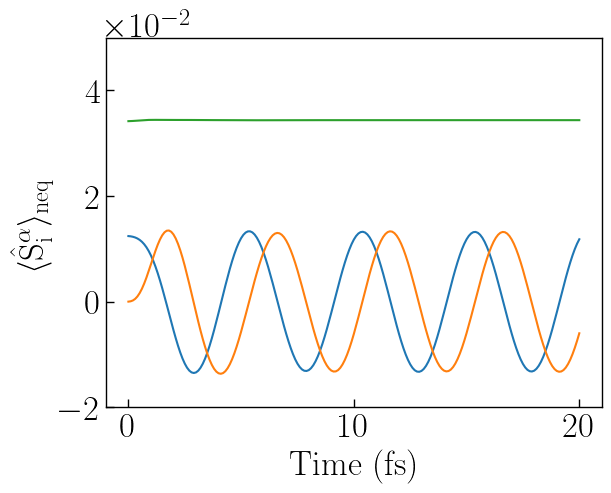

PyObject <matplotlib.legend.Legend object at 0x7f9187a11f40>

In [17]:


fig,axs = plt.subplots(1,1)
fs=25
site = 1

axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.plot(ts,sden[site,1,:])
plt.plot(ts,sden[site,2,:])
plt.plot(ts,sden[site,3,:])
#plt.xlim(90,100)
#plt.xlim(98,120)
#plt.ylim(-1,1)
#plt.xlim([0,22])
plt.ylim(-2e-2,5e-2)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))



In [18]:
ceil(1.3)

2.0

In [19]:
#Int(1.3)

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


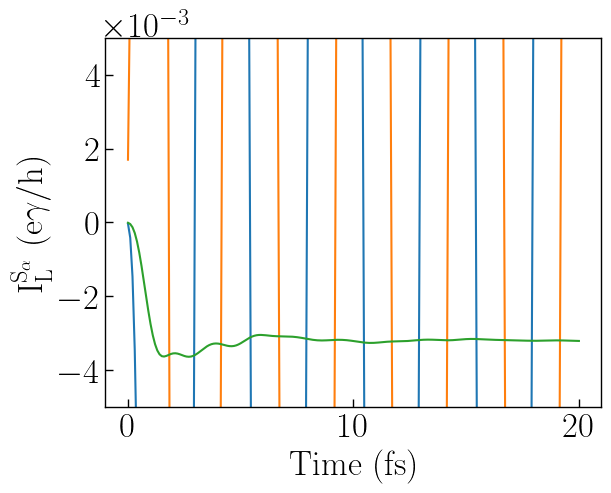

PyObject <matplotlib.legend.Legend object at 0x7f91729625d0>

In [20]:

fig,axs = plt.subplots(1,1)

plt.plot(ts,curr[1,:]*2pi)
plt.plot(ts,curr[2,:]*2pi)
plt.plot(ts,curr[3,:]*2pi)

axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#plt.xlim(98,120)
#plt.ylim(-1.1e-10,1.1e-10)
plt.ylim(-0.005,0.005)
#plt.xlim([0,22])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))